In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv("/scratch/gpfs/TEYSSIER/jp7427/FVvsSD/sinus-timing/timing_results.csv")

UNLIMITED_ROUTINES = (
    "compute_dt",
    "update_unew",
    "primitive_conservative",
    "boundary_conditions",
    "stencil_sweep",
    "einsum",
    "transpose",
    "riemann_solver",
)

BREAKDOWN_ROUTINES = tuple(cat for cat in UNLIMITED_ROUTINES if cat != "update_unew")
TARGET_NDOF = 3072

ROUTINE_LABELS = {
    "compute_dt": "compute dt",
    "primitive_conservative": "prim/cons",
    "boundary_conditions": "BCs",
    "stencil_sweep": "stencils",
    "einsum": "einsums",
    "transpose": "transposes",
    "riemann_solver": "Riemann",
}

for cat in UNLIMITED_ROUTINES:
    col = f"{cat}_per_step"
    if col not in df:
        df[col] = 0.0

if "total_per_step" not in df:
    df["total_per_step"] = df["NDOF"] ** 2 / df["update_rate"]

breakdown_cols = [f"{cat}_per_step" for cat in BREAKDOWN_ROUTINES]
df["timed_per_step"] = df[breakdown_cols].sum(axis=1)
df["untimed_per_step"] = (df["total_per_step"] - df["timed_per_step"]).clip(lower=0.0)


def plot(ax, frame, quantity, **kwargs):
    if frame.empty:
        return
    ax.plot(frame.NDOF, frame[quantity], marker="o", **kwargs)

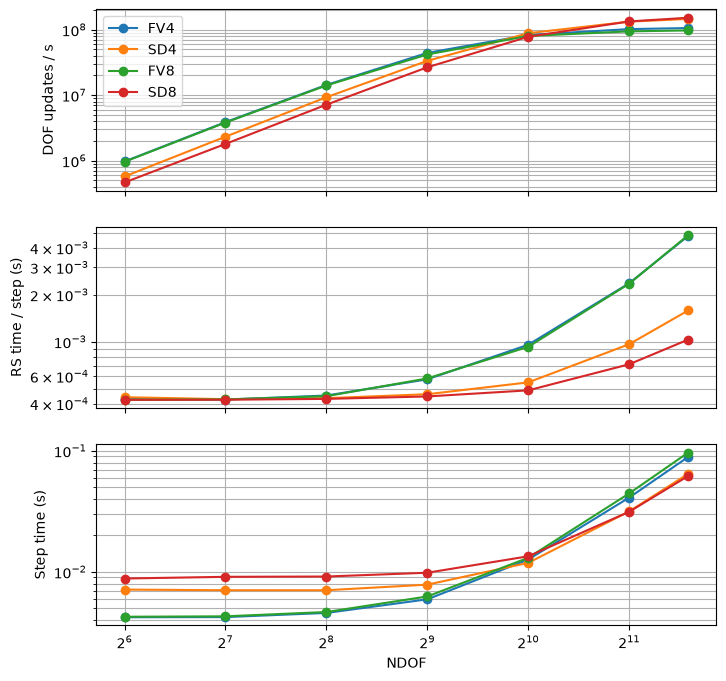

In [2]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
axs[2].set_xlabel("NDOF")
axs[0].set_ylabel("DOF updates / s")
axs[1].set_ylabel("RS time / step (s)")
axs[2].set_ylabel("Step time (s)")
axs[0].set_xscale("log", base=2)
for ax in axs:
    ax.set_yscale("log")

for scheme, p, label in (("FV", 3, "FV4"), ("SD", 3, "SD4"), ("FV", 7, "FV8"), ("SD", 7, "SD8")):
    frame = df[(df.scheme == scheme) & (df.p == p)].sort_values("NDOF")
    plot(axs[0], frame, "update_rate", label=label)
    plot(axs[1], frame, "rs_per_step", label=label)
    plot(axs[2], frame, "total_per_step", label=label)

for ax in axs:
    ax.grid(which="both")
axs[0].legend()

fig.savefig("update-rates.pdf", bbox_inches="tight")

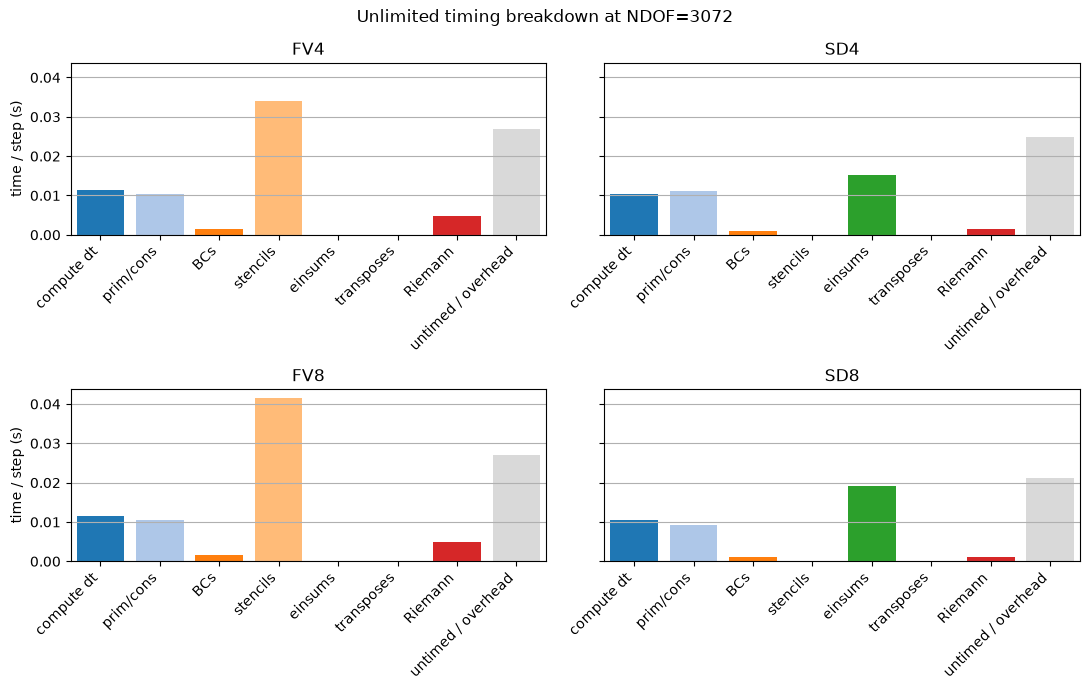

In [3]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(11, 7))
fig.suptitle(f"Unlimited timing breakdown at NDOF={TARGET_NDOF}")

cases = (("FV", 3, "FV4"), ("SD", 3, "SD4"), ("FV", 7, "FV8"), ("SD", 7, "SD8"))
bar_cats = BREAKDOWN_ROUTINES + ("untimed_per_step",)
bar_labels = [ROUTINE_LABELS.get(cat, "untimed / overhead") for cat in bar_cats]
colors = list(plt.get_cmap("tab20").colors[: len(BREAKDOWN_ROUTINES)]) + ["0.85"]

for ax, (scheme, p, title) in zip(axs.flat, cases):
    frame = df[(df.scheme == scheme) & (df.p == p) & (df.NDOF == TARGET_NDOF)]
    x = np.arange(len(bar_cats))
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=45, ha="right")

    if not frame.empty:
        row = frame.iloc[-1]
        values = [row[f"{cat}_per_step"] for cat in BREAKDOWN_ROUTINES]
        values.append(row["untimed_per_step"])
        ax.bar(x, values, color=colors)
    else:
        ax.text(0.5, 0.5, "missing NDOF", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlim(-0.5, len(bar_cats) - 0.5)
    ax.grid(axis="y")

for ax in axs[:, 0]:
    ax.set_ylabel("time / step (s)")

fig.tight_layout()
fig.savefig("unlimited-breakdown.pdf", bbox_inches="tight")